# Machine Learning Model Deployment


- Load a trained model with MLflow and make inferences. 

## Libs

In [33]:
import os
from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.sql.types import StringType
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql import functions as F
from graphics.graphs import plot_confusion_matrix

import mlflow
import mlflow.spark
from mlflow.tracking import MlflowClient

## Dataset

In [35]:
df = spark.read.csv('data/test_df.csv', header=True, inferSchema=True)
print(df.count())
df.limit(10).toPandas()

287


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,target,features
0,tt10097442,movie,I Believe,Li Wo Yuan Yi Dian,0,2023,\N,94.0,Drama,7.0,66,0,"[66.0,0.0,2023.0,94.0]"
1,tt10171848,movie,Pigeon's Milk,Moloko ptitsy,0,2021,\N,78.0,Drama,5.2,74,0,"[74.0,0.0,2021.0,78.0]"
2,tt10218112,movie,Courageous Warriors Beauty from the Ashes,Courageous Warriors Beauty from the Ashes,0,2021,\N,91.0,Documentary,9.5,51,1,"[51.0,0.0,2021.0,91.0]"
3,tt10355512,tvMovie,Auf dem Grund,Auf dem Grund,0,2022,\N,90.0,Drama,5.7,78,0,"[78.0,0.0,2022.0,90.0]"
4,tt10441878,movie,A Mesma Parte de Um Homem,A Mesma Parte de Um Homem,0,2021,\N,99.0,Drama,6.4,88,0,"[88.0,0.0,2021.0,99.0]"
5,tt10474162,movie,Commitment to Life,Commitment to Life,0,2023,\N,115.0,Documentary,7.4,78,0,"[78.0,0.0,2023.0,115.0]"
6,tt10623178,movie,Alida,Alida,0,2021,\N,105.0,Documentary,7.8,67,1,"[67.0,0.0,2021.0,105.0]"
7,tt10690722,movie,Jess Plus None,Jess Plus None,0,2023,\N,101.0,Comedy,7.7,77,1,"[77.0,0.0,2023.0,101.0]"
8,tt10919258,movie,Evan Wood,Evan Wood,0,2021,\N,89.0,Drama,5.4,90,0,"[90.0,0.0,2021.0,89.0]"
9,tt10919446,movie,Spirit Quest,Spirit Quest,0,2021,\N,86.0,Comedy,4.3,61,0,"[61.0,0.0,2021.0,86.0]"


In [36]:
df.printSchema()

root
 |-- tconst: string (nullable = true)
 |-- titleType: string (nullable = true)
 |-- primaryTitle: string (nullable = true)
 |-- originalTitle: string (nullable = true)
 |-- isAdult: integer (nullable = true)
 |-- startYear: integer (nullable = true)
 |-- endYear: string (nullable = true)
 |-- runtimeMinutes: double (nullable = true)
 |-- genres: string (nullable = true)
 |-- averageRating: double (nullable = true)
 |-- numVotes: integer (nullable = true)
 |-- target: integer (nullable = true)
 |-- features: string (nullable = true)



## Tests

<img src="imgs/model_artifacts.png">

### Load MLflow model

In [37]:
client = MlflowClient()

model_name = 'rf_model'

versions = client.search_model_versions(
    filter_string=f'name = "{model_name}"'
)

latest = max(versions, key=lambda v: int(v.version))

model_uri = f'runs:/{latest.run_id}/random_forest_artifacts'

loaded_model = mlflow.spark.load_model(model_uri)

2026/08/30 18:26:03 INFO mlflow.spark: URI 'runs:/515751e1c41c446881c83e602bacdefd/random_forest_artifacts/sparkml' does not point to the current DFS.
2026/08/30 18:26:03 INFO mlflow.spark: File 'runs:/515751e1c41c446881c83e602bacdefd/random_forest_artifacts/sparkml' not found on DFS. Will attempt to upload the file.


In [38]:
df = df.withColumn(
    'features',
    F.udf(
        lambda x: Vectors.dense([float(v) for v in x.strip('[]').split(',')]),
        VectorUDT()
    )('features')
)

In [39]:
df.select('features').limit(3).collect()[0]['features']

DenseVector([66.0, 0.0, 2023.0, 94.0])

## df_batch

In [40]:
N = 1000

total_rows = df.count()

num_partitions = max(
    1,
    (total_rows + N - 1) // N
)

df_batch = df.repartition(num_partitions)

preds = loaded_model.transform(df_batch)

In [41]:
preds = loaded_model.transform(df)

In [42]:
preds.select(
    'target',
    'prediction',
    'probability'
).limit(10).toPandas()

26/08/30 18:26:05 WARN DAGScheduler: Broadcasting large task binary with size 1090.4 KiB


,target,prediction,probability
0,0,0.0,"[0.7823252159927742, 0.21767478400722584]"
1,0,0.0,"[0.861113112276614, 0.13888688772338598]"
2,1,0.0,"[0.8017988694576492, 0.1982011305423507]"
3,0,0.0,"[0.8113400296277335, 0.1886599703722665]"
4,0,0.0,"[0.8596313482552772, 0.14036865174472268]"
5,0,0.0,"[0.8087524192590205, 0.1912475807409794]"
6,1,0.0,"[0.8372592097516278, 0.16274079024837226]"
7,1,0.0,"[0.8061197154572267, 0.1938802845427733]"
8,0,0.0,"[0.8356255636093544, 0.1643744363906457]"
9,0,0.0,"[0.7911199386615805, 0.20888006133841963]"


In [43]:
preds.limit(5).toPandas()

26/08/30 18:26:06 WARN DAGScheduler: Broadcasting large task binary with size 1106.1 KiB


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,target,features,rawPrediction,probability,prediction
0,tt10097442,movie,I Believe,Li Wo Yuan Yi Dian,0,2023,\N,94.0,Drama,7.0,66,0,"[66.0, 0.0, 2023.0, 94.0]","[156.46504319855492, 43.53495680144519]","[0.7823252159927742, 0.21767478400722584]",0.0
1,tt10171848,movie,Pigeon's Milk,Moloko ptitsy,0,2021,\N,78.0,Drama,5.2,74,0,"[74.0, 0.0, 2021.0, 78.0]","[172.22262245532278, 27.77737754467719]","[0.861113112276614, 0.13888688772338598]",0.0
2,tt10218112,movie,Courageous Warriors Beauty from the Ashes,Courageous Warriors Beauty from the Ashes,0,2021,\N,91.0,Documentary,9.5,51,1,"[51.0, 0.0, 2021.0, 91.0]","[160.35977389152978, 39.640226108470124]","[0.8017988694576492, 0.1982011305423507]",0.0
3,tt10355512,tvMovie,Auf dem Grund,Auf dem Grund,0,2022,\N,90.0,Drama,5.7,78,0,"[78.0, 0.0, 2022.0, 90.0]","[162.26800592554673, 37.731994074453304]","[0.8113400296277335, 0.1886599703722665]",0.0
4,tt10441878,movie,A Mesma Parte de Um Homem,A Mesma Parte de Um Homem,0,2021,\N,99.0,Drama,6.4,88,0,"[88.0, 0.0, 2021.0, 99.0]","[171.92626965105555, 28.073730348944554]","[0.8596313482552772, 0.14036865174472268]",0.0


## Model eval

In [ ]:
auc = BinaryClassificationEvaluator(
    labelCol='Target',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
).evaluate(preds)

print(f'ROC-AUC: {auc:.4f}')

26/08/30 18:26:06 WARN DAGScheduler: Broadcasting large task binary with size 1085.0 KiB


ROC-AUC: 0.6087


In [ ]:
pr_auc = BinaryClassificationEvaluator(
    labelCol='Target',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderPR'
).evaluate(preds)

print(f'PR-AUC: {pr_auc:.4f}')

26/08/30 18:26:07 WARN DAGScheduler: Broadcasting large task binary with size 1085.0 KiB


PR-AUC: 0.3523


In [ ]:
evaluator = MulticlassClassificationEvaluator(
    labelCol='target',
    predictionCol='prediction'
)

accuracy = evaluator.setMetricName(
    'accuracy'
).evaluate(preds)

f1 = evaluator.setMetricName(
    'f1'
).evaluate(preds)

precision = evaluator.setMetricName(
    'weightedPrecision'
).evaluate(preds)

recall = evaluator.setMetricName(
    'weightedRecall'
).evaluate(preds)

print(f'Accuracy : {accuracy:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')

26/08/30 18:26:08 WARN DAGScheduler: Broadcasting large task binary with size 1098.1 KiB
26/08/30 18:26:08 WARN DAGScheduler: Broadcasting large task binary with size 1098.1 KiB
26/08/30 18:26:08 WARN DAGScheduler: Broadcasting large task binary with size 1098.1 KiB
26/08/30 18:26:08 WARN DAGScheduler: Broadcasting large task binary with size 1098.1 KiB


Accuracy : 0.7805
F1 Score : 0.6995
Precision: 0.7847
Recall   : 0.7805


## Confusion matrix

26/08/30 18:26:08 WARN DAGScheduler: Broadcasting large task binary with size 1097.7 KiB
26/08/30 18:26:08 WARN DAGScheduler: Broadcasting large task binary with size 1097.7 KiB


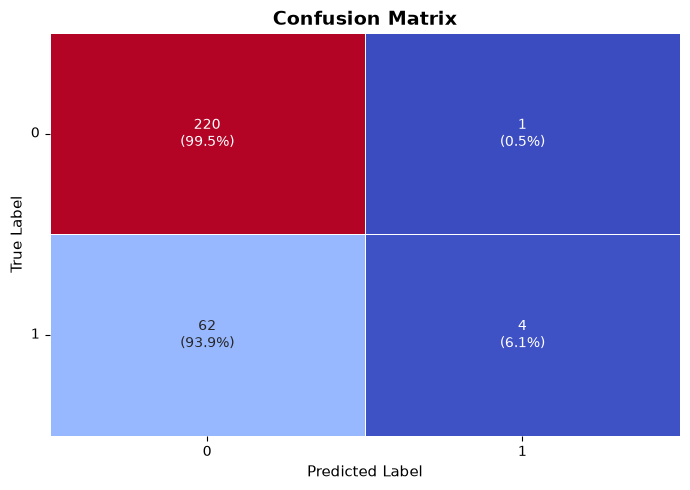

In [48]:
plot_confusion_matrix(preds)